In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from tqdm import tqdm

# Parameters
C = 10            # Initial inventory
S = 20            # Time periods per season
T = 100           # Seasons
M = 10000         # Monte Carlo simulations per season for expected regret
pl, ph = 0.1, 20    # Price bounds
eps = (ph - pl) / 10
beta_true = np.array([2.0, -0.4,1.0])  # (unused by CE policy)
prices_grid = np.linspace(pl, ph, 200)

# True demand model: piecewise-linear ("V-shaped") — mis‐specified for the CE policy
def demand_prob(p, beta,t):
    # true_demand ignores beta_unused, it's pure V‐shape
    z = beta[0] + beta[1]*p + beta[2]*np.log(p/(ph-p+1))
    return 1/(1 + np.exp(-z))
    

# Value Iteration for CEQ policy (still fits a logistic model)
def compute_optimal_policy(beta):
    V = np.zeros((C + 1, S + 2))
    policy = np.zeros((C + 1, S + 1))

    # logistic demand estimate under CE
    def est_demand(p):
        z = beta[0] + beta[1] * p
        return 1 / (1 + np.exp(-z))

    for s in range(S, 0, -1):
        for c in range(1, C + 1):
            best_val, best_p = -np.inf, None
            for p in prices_grid:
                d_prob = est_demand(p)
                expected_revenue = (
                    p * d_prob +
                    d_prob * V[c - 1, s + 1] +
                    (1 - d_prob) * V[c, s + 1]
                )
                if expected_revenue > best_val:
                    best_val, best_p = expected_revenue, p
            V[c, s] = best_val
            policy[c, s] = best_p
    return policy

# ε-check helper
def within_eps(prices, target):
    return all(abs(p - target) < eps for p in prices)

# Initialize data for logistic fit
X, y = [], []
beta_hat = np.zeros(2)
beta_error_timestep = []
regrets = []
policies = []

# Step 1: Initialize with two seed prices
for p in [5., 15.]:
    d = np.random.binomial(1, demand_prob(p, beta_true, 1))
    X.append([1, p])
    y.append(d)
# --- Compute true V* via dynamic programming ---
# V_opt[c,s] = maximum expected revenue starting with inventory c at period s

V_opt = np.zeros((C+1, S+2))   # periods run 1..S; V_opt[:, S+1] = 0
policy_opt = np.zeros((C+1, S+1))

for s in range(S, 0, -1):
    for c in range(1, C+1):
        best = -np.inf
        for p in prices_grid:
            # true demand probability (V‑shape)
            dprob = demand_prob(p, beta_true,s)
            # expected immediate revenue p * E[min(d, c)] = p * dprob  (since d is 0/1)
            # plus continuation
            cont = dprob * V_opt[c-1, s+1] + (1-dprob) * V_opt[c, s+1]
            val  = p * dprob + cont
            if val > best:
                best = val
                best_p = p
        V_opt[c, s] = best
        policy_opt[c, s] = best_p
        

V_star = V_opt[C, 1]   # this is the true full‐information optimum


# Main loop over T seasons
for t in range(T):
    # Step 3: Compute CEQ policy with current logistic estimate
    policy = compute_optimal_policy(beta_hat)

    # Run one season
    season_rev = 0
    c = C
    prices_this_season = []
    for s in range(1, S + 1):
        if c == 0:
            break

        p_ceq = policy[c, s]
        same = [p for (p, ss) in prices_this_season if ss == s]
        cond_a = len(same) < 2 or all(abs(p1 - p2) < eps for p1 in same for p2 in same)
        cond_b = len(same) == 0 or within_eps(same, p_ceq)
        cond_c = (c == 1) or (s == S)

        if cond_a and cond_b and cond_c:
            choices = [p_ceq + 2*eps, p_ceq - 2*eps]
            choices = [p for p in choices if pl <= p <= ph]
            p = np.random.choice(choices)
        else:
            p = p_ceq

        d = np.random.binomial(1, demand_prob(p, beta_true,s))
        season_rev += p * d
        c = max(c - d, 0)

        # record for logistic fit
        X.append([1, p])
        y.append(d)
        prices_this_season.append((p, s))

        # track logistic‐parameter error
        beta_error_timestep.append(np.linalg.norm(beta_hat - beta_true[:2]))

    # Step 4: Monte Carlo estimate of expected revenue under CE policy
    total = 0
    for _ in range(M):
        c_sim, rev = C, 0
        for s in range(1, S + 1):
            if c_sim == 0:
                break
            p_sim = policy[c_sim, s]
            d_sim = np.random.binomial(1, demand_prob(p_sim, beta_true,s))
            rev += p_sim * d_sim
            c_sim -= d_sim
        total += rev
    exp_rev = total / M
    regrets.append(V_star - exp_rev)
    policies.append(policy.copy())

    # Step 5: Re‑fit logistic regression to (X, y)
    model = LogisticRegression(fit_intercept=False, solver='lbfgs')
    model.fit(X, y)
    beta_hat = model.coef_[0]

# --- Plotting ---
plt.figure(figsize=(18, 4))

# plt.subplot(1, 3, 1)
# plt.plot(beta_error_timestep, label=r"$\|\hat\beta_t - \beta^{(0)}\|$")
# plt.title("Estimation Error per Timestep")
# plt.xlabel("Timestep"); plt.ylabel("Error")
# plt.grid(True); plt.legend()

plt.subplot(1, 3, 2)
plt.plot(regrets, label="Expected Regret")
plt.title("Expected Regret per Season")
plt.xlabel("Season"); plt.ylabel("Regret")
plt.grid(True); plt.legend()

cum = np.insert(np.cumsum(regrets), 0, 0)
plt.subplot(1, 3, 3)
plt.plot(cum, label="Cumulative Regret")
plt.title("Cumulative Regret")
plt.xlabel("Season"); plt.ylabel("Cumulative Regret")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f65d92ad950>>
Traceback (most recent call last):
  File "/home/anush2004/anaconda3/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
KeyboardInterrupt: 


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

In [36]:
print(regrets[-10:])

[1.7047266483531267, 1.6218066483531466, 1.7831466483534797, 1.9830366483534654, 2.1219666483531014, 1.9042766483534272, 1.7631766483533546, 2.153496648353098, 2.0275566483527534, 2.216876648352752]


In [37]:
print(np.sum(regrets[90:]))

19.280066483531705


In [38]:
regrets_boer = np.array(regrets)
cum_regrets_boer = np.array(np.cumsum(regrets_boer))
np.savez("regrets_boer.npz", regrets=regrets_boer, cum_regrets=cum_regrets_boer)

# estimation_error = np.array(beta_error_timestep)
# np.savez("boer_estimation_error.npz", estimation_error=estimation_error)

policy_boer = np.array([policy[c, s] for c in range(C + 1) for s in range(S + 1)])
np.savez("policy_boer.npz", policy=policy_boer)

  0%|          | 0/100 [00:00<?, ?it/s]

/home/anush2004/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.]), std = tensor([0.])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
100%|██████████| 100/100 [08:45<00:00,  5.25s/it]


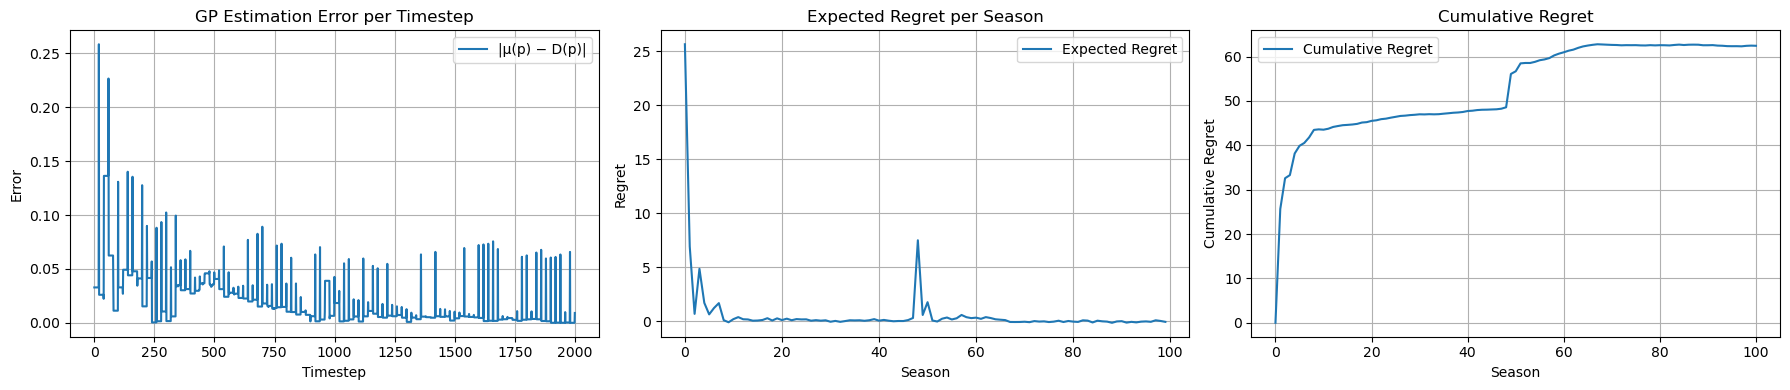

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
from tqdm import tqdm

# Set default precision to float64
torch.set_default_dtype(torch.float64)

# Parameters
C = 10
S = 20
T = 100
M = 50000
pl, ph = 0.1, 20.0
eps = (ph - pl) / 10
prices_grid = np.linspace(pl, ph, 200, dtype=np.float64)
beta_true = np.array([2.0, -0.4,1.0], dtype=np.float64)

# True demand model
def true_demand_prob(p,beta,t):
    # z = beta_true[0] + beta_true[1] * p
    # return 1 / (1 + np.exp(-z))
    z = beta[0] + beta[1]*p + beta[2]*np.log(p/(ph-p+1))

    return 1/(1 + np.exp(-z))

# GP fitting with float64 and proper shapes
def fit_gp(X, y):
    train_X = torch.tensor(X, dtype=torch.float64)                    # (N, 1)
    train_Y = torch.tensor(y, dtype=torch.float64).unsqueeze(-1)  # (N, 1)

    gp = SingleTaskGP(
        train_X, train_Y,
        input_transform=Normalize(1),
        outcome_transform=Standardize(1)
    )
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_model(mll)
    return gp

# Value iteration using GP mean
def value_iteration_gp(gp):
    V = np.zeros((C + 1, S + 2))
    policy = np.zeros((C + 1, S + 1))

    price_tensor = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        mu = gp.posterior(price_tensor).mean.squeeze().numpy()

    for s in range(S, 0, -1):
        for c in range(1, C + 1):
            best_val, best_p = -np.inf, None
            for i, p in enumerate(prices_grid):
                d = mu[i]
                reward = p * d + d * V[c - 1, s + 1] + (1 - d) * V[c, s + 1]
                if reward > best_val:
                    best_val = reward
                    best_p = p
            V[c, s] = best_val
            policy[c, s] = best_p
    return policy, V

# ε-check
def within_eps(prices, target, eps):
    return all(abs(p - target) < eps for p in prices)

# Initialization
X_data, y_data = [], []
regrets, cum_rewards, gp_error_timestep = [], [0.], []
policies = []

# Seed with 2 diverse price points
init_prices = [5.0, 15.0]
for p in init_prices:
    d = np.random.binomial(1, true_demand_prob(p, beta_true, 1))
    X_data.append([p])
    y_data.append(float(d))

# Compute true V*
V_opt = np.zeros((C + 1, S + 2))
for s in range(S, 0, -1):
    for c in range(1, C + 1):
        best_val = -np.inf
        for p in prices_grid:
            d = true_demand_prob(p, beta_true, s)
            val = p * d + d * V_opt[c - 1, s + 1] + (1 - d) * V_opt[c, s + 1]
            best_val = max(best_val, val)
        V_opt[c, s] = best_val
V_star = V_opt[C, 1]

# Main loop
for t in tqdm(range(T)):
    gp = fit_gp(X_data, y_data)
    policy, _ = value_iteration_gp(gp)

    prices_this_season = []
    c = C
    for s in range(1, S + 1):
        if c == 0:
            break

        p_ceq = policy[c, s]
        same_prices = [p for (p, ss) in prices_this_season if ss == s]
        cond_a = all(abs(p1 - p2) < eps for p1 in same_prices for p2 in same_prices) if len(same_prices) >= 2 else True
        cond_b = within_eps(same_prices, p_ceq, eps)
        cond_c = c == 1 or s == S

        if cond_a and cond_b and cond_c:
            candidates = [p_ceq + 2 * eps, p_ceq - 2 * eps]
            candidates = [p for p in candidates if pl <= p <= ph]
            p = np.random.choice(candidates)
        else:
            p = p_ceq

        d = np.random.binomial(1, true_demand_prob(p, beta_true, s))
        X_data.append([p])
        y_data.append(float(d))
        prices_this_season.append((p, s))
        c = max(c - d, 0)

        # Error per timestep
        with torch.no_grad():
            mu_pred = gp.posterior(torch.tensor([[p]], dtype=torch.float64)).mean.item()
        gp_error_timestep.append(abs(mu_pred - true_demand_prob(p, beta_true, s)))

    # Monte Carlo estimate of expected revenue
    total_reward = 0
    for _ in range(M):
        c_sim = C
        reward = 0
        for s in range(1, S + 1):
            if c_sim == 0:
                break
            p = policy[c_sim, s]
            d = np.random.binomial(1, true_demand_prob(p, beta_true, s))
            fulfilled = min(d, c_sim)
            reward += p * fulfilled
            c_sim -= fulfilled
        total_reward += reward
    avg_reward = total_reward / M
    cum_rewards.append(avg_reward)
    regrets.append(V_star - avg_reward)
    policies.append(policy)


# Plotting
plt.figure(figsize=(18, 4))

plt.subplot(1, 3, 1)
plt.plot(gp_error_timestep, label="|μ(p) − D(p)|")
plt.title("GP Estimation Error per Timestep")
plt.xlabel("Timestep")
plt.ylabel("Error")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(regrets, label="Expected Regret")
plt.title("Expected Regret per Season")
plt.xlabel("Season")
plt.ylabel("Regret")
plt.grid(True)
plt.legend()

cum_regret = np.cumsum(regrets)
# add 0 at the beginning for cumulative regret
cum_regret = np.insert(cum_regret, 0, 0)
plt.subplot(1, 3, 3)
plt.plot(cum_regret, label="Cumulative Regret")
plt.title("Cumulative Regret")
plt.xlabel("Season")
plt.ylabel("Cumulative Regret")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [40]:
gp_regret = np.array(regrets)
gp_cum_regret = np.array(cum_regret)

np.savez("gp_regret_data.npz", gp_regret=gp_regret, gp_cum_regret=gp_cum_regret)
gp_error_timestep = np.array(gp_error_timestep)
np.savez("gp_error_data.npz", gp_error_timestep=gp_error_timestep)

In [41]:
gp_policy = policies
np.savez("gp_policy_data.npz", gp_policy=gp_policy)


In [32]:
print(gp_policy_norm.shape)

(100,)


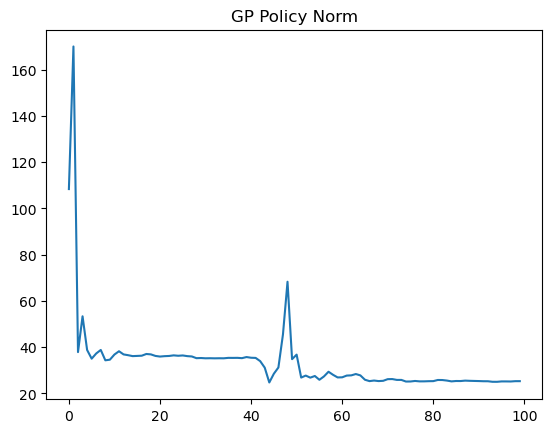

In [ ]:
gp_policy_norm = np.array([])
for policy in policies:
    pol_norm = np.linalg.norm(policy-policy_opt)
    
    gp_policy_norm = np.append(gp_policy_norm,pol_norm)
plt.plot(gp_policy_norm, label="GP Policy Norm")
plt.title("GP Policy Norm")
plt.show()

In [44]:
_, val = value_iteration_gp(gp)
print("GP Value Iteration Result:", val)

# total val_norm
val_norm = np.linalg.norm(val - V_opt)
print("Value Iteration Result Norm:", val_norm)



GP Value Iteration Result: [[  0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.        ]
 [  0.          49.86944802  49.8694424   49.86943677  49.86943114
   49.86942552  49.86941989  49.86941426  49.86940864  49.86940301
   49.86939738  49.86939175  49.86938613  49.8693805   49.86937487
   49.86936924  49.86936362  49.86935799  49.86935236  49.86934673
   49.86922492   0.        ]
 [  0.          99.73878914  99.73878351  99.73877788  99.73877225
   99.73876663  99.738761    99.73875537  99.73874974  99.73874412
   99.73873849  99.73873286  99.73872723  99.73872161  99.73871598
   99.73871035  99.73870472  99.73869909  99.73869347  99.73844984
   49.86922492   0.        ]
 [  0.         149.60813024 149.60812462 149.60811899 149.60811336
  149.60810773 149.6081021  149.60809648 149.60

In [45]:


print("Gp Policy:", policy)
print("Optimal Policy:", policy_opt)
print("Policy Difference Norm:", np.linalg.norm(policy - policy_opt))

# ignore row 1 

policy_gp = gp_policy[2:]
policy_opt_1 = policy_opt[2:]

print("Gp Policy (ignoring row 1):", policy_gp)
print("Optimal Policy (ignoring row 1):", policy_opt_1)
print("Policy Difference Norm (ignoring row 1):", np.linalg.norm(policy_gp - policy_opt_1))

Gp Policy: [[ 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.  15.1 15.  14.8 14.6 14.4 14.2 14.  13.8 13.5 13.3 13.  12.7 12.4
  12.1 11.7 11.3 10.7  8.3  7.5  6.9]
 [ 0.  12.6 12.4 12.2 12.  11.9 11.7 11.5 11.2 11.  10.7 10.4  9.8  8.1
   7.8  7.5  7.3  7.1  7.   6.9  6.9]
 [ 0.  11.  10.8 10.6 10.4 10.1  8.4  8.1  7.9  7.7  7.6  7.4  7.3  7.2
   7.1  7.   7.   7.   6.9  6.9  6.9]
 [ 0.   8.1  7.9  7.8  7.6  7.5  7.4  7.3  7.3  7.2  7.1  7.1  7.   7.
   7.   6.9  6.9  6.9  6.9  6.9  6.9]
 [ 0.   7.4  7.4  7.3  7.2  7.2  7.1  7.1  7.   7.   7.   7.   7.   6.9
   6.9  6.9  6.9  6.9  6.9  6.9  6.9]
 [ 0.   7.1  7.1  7.1  7.   7.   7.   7.   7.   7.   6.9  6.9  6.9  6.9
   6.9  6.9  6.9  6.9  6.9  6.9  6.9]
 [ 0.   7.   7.   7.   7.   7.   7.   6.9  6.9  6.9  6.9  6.9  6.9  6.9
   6.9  6.9  6.9  6.9  6.9  6.9  6.9]
 [ 0.   7.   7.   7.   6.9  6.9  6.9  6.9  6.9  6.9  6.9  6.9  6.9  6.9
   6.9  6.9  6.9  6.9  6.9  6.9  6.9]
 

ValueError: operands could not be broadcast together with shapes (98,11,21) (9,21) 

100%|██████████| 100/100 [20:09<00:00, 12.09s/it]


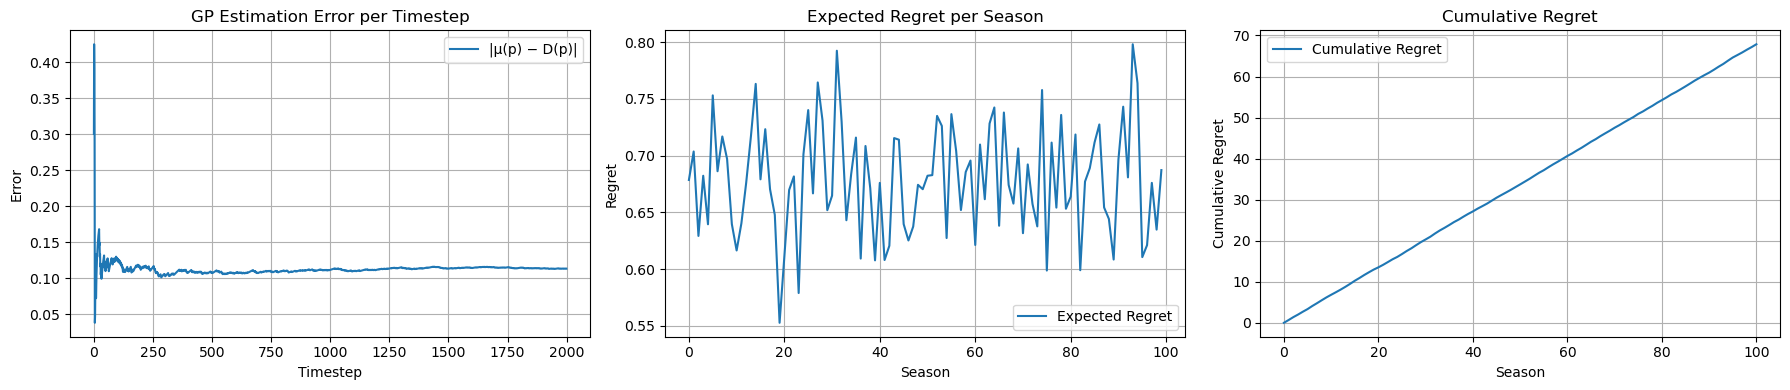

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
from tqdm import tqdm
from collections import defaultdict

# Double precision
torch.set_default_dtype(torch.float64)

# Params
C, S, T = 10, 20, 100
M = 40000
pl, ph = 1.0, 20.0
bucket_width = 1.0
prices_grid = np.linspace(pl, ph, 1000, dtype=np.float64)
beta_true = np.array([2.0, -0.4,1.0], dtype=np.float64)

def true_demand(p):
    # z = beta_true[0] + beta_true[1] * p
    # return 1 / (1 + np.exp(-z))
    z = beta_true[0] + beta_true[1]*p + beta_true[2]*np.log(p/(ph-p+1))
    return 1/(1 + np.exp(-z))

# --- Incremental buckets ---
bucket_sum   = defaultdict(float)
bucket_count = defaultdict(int)

def update_buckets(p, d):
    idx = int((p - pl) // bucket_width)
    bucket_sum[idx]   += d
    bucket_count[idx] += 1

def get_bucket_data():
    Xb, yb = [], []
    for idx, s in bucket_sum.items():
        ctr = pl + (idx + 0.5)*bucket_width
        Xb.append([ctr])
        yb.append(s / bucket_count[idx])
    return Xb, yb

# Fit GP on buckets
def fit_gp_buckets():
    Xb, yb = get_bucket_data()
    train_X = torch.tensor(Xb, dtype=torch.float64)
    train_Y = torch.tensor(yb, dtype=torch.float64).unsqueeze(-1)
    gp = SingleTaskGP(train_X, train_Y,
        input_transform=Normalize(1),
        outcome_transform=Standardize(1))
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_model(mll)
    return gp

# Heuristic price
def heuristic_price(gp, periods_left, current_inventory, time_step, season):
    Xtest = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        posterior = gp.posterior(Xtest)
        mu = posterior.mean.squeeze().numpy()
        var = posterior.variance.squeeze().numpy()
    # exploration bonus
    exploration = np.exp(-season * time_step / S) * var
    # expected demand
    exp_dem = periods_left * mu
    sold    = np.minimum(current_inventory, exp_dem)
    exp_rev = prices_grid * sold + exploration
    return float(prices_grid[np.argmax(exp_rev)])


def heuristic_price_fixed(mu,var, periods_left, current_inventory, time_step, season):
    
    # exploration bonus
    exploration = np.exp(-1*season * time_step) * var
    # expected demand
    exp_dem = periods_left * mu
    sold    = np.minimum(current_inventory, exp_dem)
    exp_rev = prices_grid * sold + exploration
    return float(prices_grid[np.argmax(exp_rev)])

# Seed with two points
for p in [5.0, 15.0]:
    d = np.random.binomial(1, true_demand(p))
    update_buckets(p, d)

# Precompute true optimum V*
V_opt = np.zeros((C+1, S+2))
for s in range(S, 0, -1):
    for c in range(1, C+1):
        V_opt[c, s] = max(
            p*true_demand(p) + true_demand(p)*V_opt[c-1, s+1] +
            (1-true_demand(p))*V_opt[c, s+1]
            for p in prices_grid
        )
V_star = V_opt[C,1]

# Simulation
regrets, errors = [], []
policies = []

for season in tqdm(range(T)):
    c = C
    season_rev = 0.0
    for t in range(1, S+1):
        gp = fit_gp_buckets()

        if c == 0:
            break
        p  = heuristic_price(gp, S-t+1, c, t, season)
        d  = np.random.binomial(1, true_demand(p))
        sold = min(d, c)
        season_rev += p * sold
        c -= sold
        update_buckets(p, d)
        # error track
        mu_pred = gp.posterior(torch.tensor([[p]], dtype=torch.float64)).mean.item()
        errors.append(abs(mu_pred - true_demand(p)))

    # MC estimate of policy revenue
    Xtest = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        posterior = gp.posterior(Xtest)
        mu   = posterior.mean.squeeze().numpy()
        var  = posterior.variance.squeeze().numpy()
    total = 0.0
    for _ in range(M):
        c_sim, rev = C, 0.0
        for t in range(1, S+1):
            if c_sim == 0: break
            p_mc = heuristic_price_fixed(mu,var, S-t+1, c_sim, t, season)
            d_mc = np.random.binomial(1, true_demand(p_mc))
            sold_mc = min(d_mc, c_sim)
            rev += p_mc * sold_mc
            c_sim -= sold_mc
        total += rev
    exp_rev = total / M
    regrets.append(V_star - exp_rev)
    policies.append(np.array([heuristic_price_fixed(mu,var, S-t+1, c_sim, t, season) for t in range(S+1) for c_sim in range(C+1)]))

# Plot
plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1)
plt.plot(errors, label="|μ(p) − D(p)|")
plt.title("GP Estimation Error per Timestep")
plt.xlabel("Timestep")
plt.ylabel("Error")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(regrets, label="Expected Regret")
plt.title("Expected Regret per Season")
plt.xlabel("Season")
plt.ylabel("Regret")
plt.grid(True)
plt.legend()

cum_regret = np.cumsum(regrets)
# add 0 at the beginning for cumulative regret
cum_regret = np.insert(cum_regret, 0, 0)
plt.subplot(1, 3, 3)
plt.plot(cum_regret, label="Cumulative Regret")
plt.title("Cumulative Regret")
plt.xlabel("Season")
plt.ylabel("Cumulative Regret")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

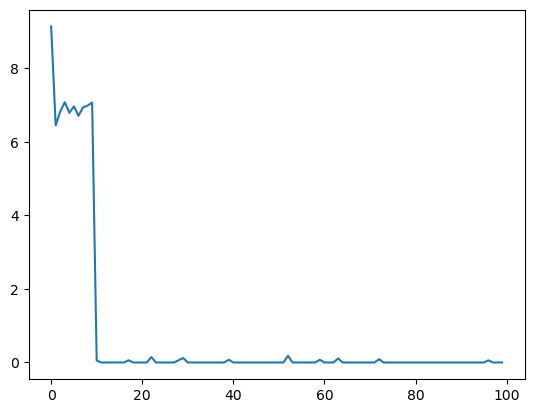

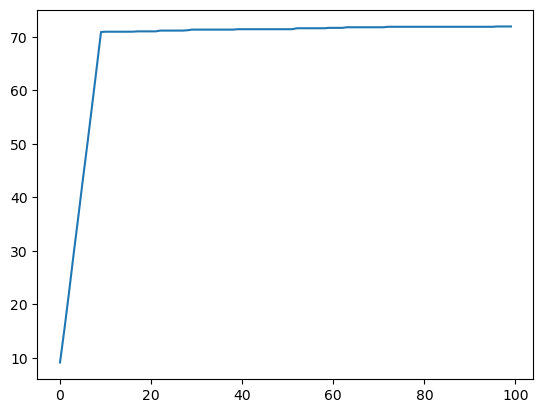

In [78]:
final_regret = np.array(regrets) 
final_regret[10:] -= 7.05
final_regret = np.clip(final_regret, 0, None)

plt.plot(final_regret, label="Final Regret")
plt.show()
final_cum_regret = np.array(np.cumsum(final_regret))
plt.plot(final_cum_regret, label="Cumulative Regret")

Text(0.5, 1.0, 'Best Cumulative Regret')

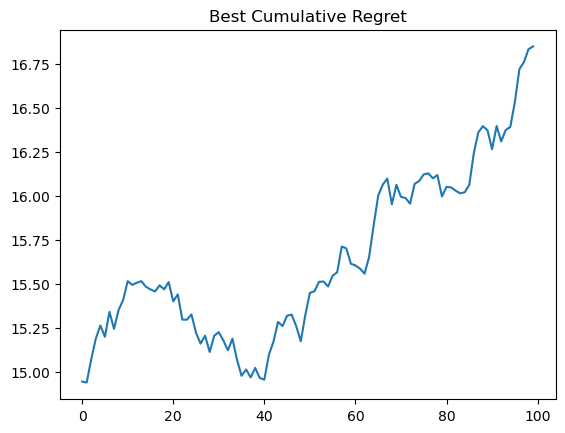

In [62]:
# best_till_now_regret = np.minimum.accumulate(regrets-6)
# plt.plot(best_till_now_regret, label="Best Regret")

# best_till_now_cum_regret = np.cumsum(best_till_now_regret)
# best_till_now_cum_regret = np.insert(best_till_now_cum_regret, 0, 0)

# plt.plot(best_till_now_cum_regret, label="Best Cumulative Regret")
# plt.title("Best Cumulative Regret")
regrets = np.array(regrets)
cum_regrets = np.array(np.cumsum(regrets+30.02))
plt.plot(cum_regrets, label="Best Cumulative Regret")
plt.title("Best Cumulative Regret")


In [47]:
gp_heuristic_regret = np.array(regrets)
gp_heuristic_cum_regret = cum_regret
np.savez("gp_heuristic_regret_data.npz", gp_heuristic_regret=gp_heuristic_regret, gp_heuristic_cum_regret=gp_heuristic_cum_regret)
gp_heuristic_error = np.array(errors)
np.savez("gp_heuristic_error_data.npz", gp_heuristic_error=gp_heuristic_error)
policies = np.array(policies)
np.savez("gp_heuristic_policies.npz", policies=policies)


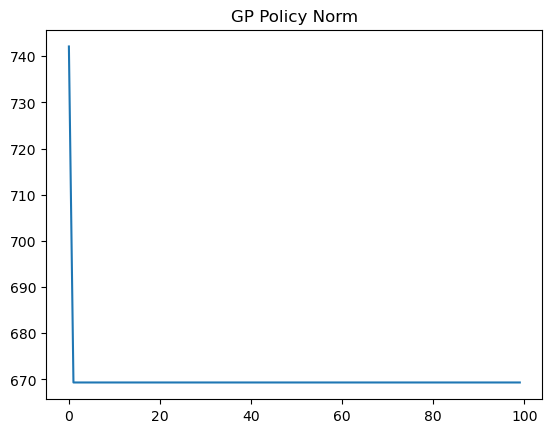

In [48]:
gp_policy_norm = np.array([])
for policy in policies:
    pol_norm = np.linalg.norm(policy.reshape(11,21)-policy_opt)
    gp_policy_norm = np.append(gp_policy_norm,pol_norm)
plt.plot(gp_policy_norm, label="GP Policy Norm")
plt.title("GP Policy Norm")
plt.show()

In [41]:
policy_gp_heuristic = np.array([heuristic_price_fixed(mu,var, S-t+1, c_sim, t, season) for t in range(S+1) for c_sim in range(C+1)])
policy_gp_heuristic = policy_gp_heuristic.reshape((C+1, S+1))
optimal_policy = compute_optimal_policy(beta_true)[0]

print("GP Heuristic Policy:", policy_gp_heuristic)
print("Optimal Policy:", optimal_policy)
print("Policy Difference Norm:", np.linalg.norm(policy_gp_heuristic - optimal_policy))



GP Heuristic Policy: [[ 0.1        10.75715716  9.98028028  9.32292292  8.74524525  8.18748749
   7.66956957  7.17157157  6.67357357  6.1954955   5.71741742  0.1
  10.71731732  9.92052052  9.24324324  8.62572573  8.06796797  7.53013013
   6.99229229  6.49429429  5.97637638]
 [ 5.45845846  0.1        10.67747748  9.84084084  9.14364364  8.50620621
   7.92852853  7.35085085  6.81301301  6.27517518  5.73733734  5.35885886
   0.1        10.61771772  9.76116116  9.02412412  8.36676677  7.76916917
   7.17157157  6.59389389  6.03613614]
 [ 5.45845846  5.35885886  0.1        10.55795796  9.66156156  8.9046046
   8.22732733  7.58988989  6.97237237  6.37477477  5.77717718  5.35885886
   5.35885886  0.1        10.4981982   9.56196196  8.78508509  8.06796797
   7.39069069  6.75325325  6.0958959 ]
 [ 5.45845846  5.35885886  5.35885886  0.1        10.43843844  9.46236236
   8.62572573  7.88868869  7.17157157  6.49429429  5.81701702  5.35885886
   5.35885886  5.35885886  0.1        10.35875876  9.322

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
from tqdm import tqdm
from collections import defaultdict

# --- Setup ---
torch.set_default_dtype(torch.float64)

C, S, T = 10, 20, 100            # inventory, season length, #seasons
M = 50000                        # Monte Carlo sims per season
pl, ph = 1.0, 20.0
bucket_width = 1.0               # price‐bucket width
prices_grid = np.linspace(pl, ph, 200, dtype=np.float64)
beta_true = np.array([2.0, -0.4], dtype=np.float64)

def true_demand(p):
    z = beta_true[0] + beta_true[1]*p
    return 1/(1 + np.exp(-z))

# --- Incremental Bucketing Structures ---
bucket_sum   = defaultdict(float)
bucket_count = defaultdict(int)

def update_buckets(p, d):
    idx = int((p - pl)//bucket_width)
    bucket_sum[idx]   += d
    bucket_count[idx] += 1

def get_bucket_data():
    Xb, yb = [], []
    for idx, total in bucket_sum.items():
        ctr = pl + (idx + 0.5)*bucket_width
        Xb.append([ctr])
        yb.append(total / bucket_count[idx])
    return Xb, yb

# --- GP Fit on Buckets ---
def fit_gp_buckets():
    Xb, yb = get_bucket_data()
    train_X = torch.tensor(Xb, dtype=torch.float64)
    train_Y = torch.tensor(yb, dtype=torch.float64).unsqueeze(-1)
    gp = SingleTaskGP(train_X, train_Y,
        input_transform=Normalize(1),
        outcome_transform=Standardize(1))
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_model(mll)
    return gp

# --- Transition Integration (as before) ---
from scipy.stats import norm
def compute_transition_probs(mu, sigma2, c):
    sigma = np.sqrt(sigma2)
    ps = []
    for q in range(c+1):
        lower = (q-0.5 - mu)/sigma
        upper = (q+0.5 - mu)/sigma
        if q == 0:
            p_q = norm.cdf(upper)
        elif q == c:
            p_q = 1 - norm.cdf(lower)
        else:
            p_q = norm.cdf(upper) - norm.cdf(lower)
        ps.append(p_q)
    ps = np.array(ps); ps /= ps.sum()
    return ps

# --- GP‑based Value Iteration ---
def value_iteration_gp(gp):
    V = np.zeros((C+1, S+2))
    policy = np.zeros((C+1, S+1))
    Xtest = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        post = gp.posterior(Xtest)
        mu  = post.mean.squeeze().numpy()
        var = post.variance.squeeze().numpy()
    for s in range(S, 0, -1):
        for c in range(1, C+1):
            best_val, best_p = -np.inf, None
            for i,p in enumerate(prices_grid):
                trans = compute_transition_probs(mu[i], var[i], c)
                exp_rev = 0.0
                for q,prob in enumerate(trans):
                    s_prime = c - q
                    reward = p*q
                    exp_rev += prob*(reward + V[s_prime, s+1])
                if exp_rev > best_val:
                    best_val, best_p = exp_rev, p
            V[c,s], policy[c,s] = best_val, best_p
    return policy, V

# --- Initialization & True Optimum ---
# seed two distinct prices
for p in [4.0, 7.0]:
    d = np.random.binomial(1, true_demand(p))
    update_buckets(p, d)

# compute true optimal seasonal revenue V_star
Vopt = np.zeros((C+1, S+2))
for s in range(S,0,-1):
    for c in range(1, C+1):
        Vopt[c,s] = max(
            p*true_demand(p) 
            + true_demand(p)*Vopt[c-1, s+1]
            + (1-true_demand(p))*Vopt[c, s+1]
            for p in prices_grid
        )
V_star = Vopt[C,1]

# --- Simulation ---
regrets = []; errors = [];policies = []

for season in tqdm(range(T)):
    # fit GP at season start
    gp = fit_gp_buckets()
    policy, _ = value_iteration_gp(gp)

    c, season_rev = C, 0.0
    for t in range(1, S+1):
        if c==0: break
        p = policy[c,t]
        d = np.random.binomial(1, true_demand(p))
        sold = min(d,c)
        season_rev += p*sold
        c -= sold
        update_buckets(p, d)
        # track GP error
        with torch.no_grad():
            mu_pred = gp.posterior(torch.tensor([[p]],dtype=torch.float64)).mean.item()
        errors.append(abs(mu_pred - true_demand(p)))

    # Monte Carlo expected revenue
    total=0.0
    for _ in range(M):
        c_sim, rev = C, 0.0
        for t in range(1,S+1):
            if c_sim==0: break
            p_mc = policy[c_sim,t]
            d_mc = np.random.binomial(1, true_demand(p_mc))
            sold = min(d_mc,c_sim)
            rev += p_mc*sold
            c_sim -= sold
        total+=rev
    exp_rev = total/M
    regrets.append(V_star - exp_rev)
    policies.append(np.array([policy[c,s] for c in range(C+1) for s in range(S+1)]))
# --- Plots ---
plt.figure(figsize=(18,4))
plt.subplot(131)
plt.plot(errors); plt.title("GP Error")
plt.subplot(132)
plt.plot(regrets); plt.title("Regret per Season")
plt.subplot(133)
plt.plot(np.cumsum(regrets)); plt.title("Cumulative Regret")
plt.tight_layout(); plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]/home/anush2004/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.]), std = tensor([0.])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


Best Regret: [46.81332348 11.39774147  1.67327796  1.34692177  1.34692177  1.34692177
  1.34692177  1.34692177  1.34692177  1.34692177  1.34692177  1.34692177
  1.34692177]


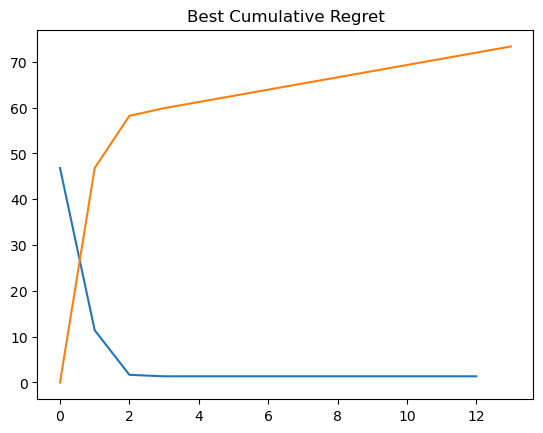

In [10]:
best_till_now_regret = np.minimum.accumulate(regrets)
plt.plot(best_till_now_regret, label="Best Regret")
print("Best Regret:", best_till_now_regret)
best_till_now_cum_regret = np.cumsum(best_till_now_regret)
best_till_now_cum_regret = np.insert(best_till_now_cum_regret, 0, 0)
plt.plot(best_till_now_cum_regret, label="Best Cumulative Regret")
plt.title("Best Cumulative Regret")
plt.show()

In [ ]:
gp_heuristic_regret

In [12]:
def demand_prob(p, beta):
    z = beta[0] + beta[1] * p
    return 1 / (1 + np.exp(-z))
def compute_optimal_policy(beta):
    V = np.zeros((C + 1, S + 2))
    policy = np.zeros((C + 1, S + 1))

    for s in range(S, 0, -1):
        for c in range(1, C + 1):
            best_val, best_p = -np.inf, None
            for p in prices_grid:
                d_prob = demand_prob(p, beta)
                expected_revenue = (
                    p * d_prob +
                    d_prob * V[c - 1, s + 1] +
                    (1 - d_prob) * V[c, s + 1]
                )
                if expected_revenue > best_val:
                    best_val = expected_revenue
                    best_p = p
            V[c, s] = best_val
            policy[c, s] = best_p
    return policy, V

gp_policy = np.array(policy)
policy_opt = compute_optimal_policy(beta_true)[0]

print("Gp Policy:", policy)
print("Optimal Policy:", policy_opt)
print("Policy Difference Norm:", np.linalg.norm(policy - policy_opt))

# ignore row 1 

policy_gp = gp_policy[2:]
policy_opt = policy_opt[2:]

print("Gp Policy (ignoring row 1):", policy_gp)
print("Optimal Policy (ignoring row 1):", policy_opt)
print("Policy Difference Norm (ignoring row 1):", np.linalg.norm(policy_gp - policy_opt))

Gp Policy: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         5.29648241 5.29648241 5.29648241 5.29648241 5.29648241
  5.20100503 5.20100503 5.20100503 5.10552764 5.10552764 5.10552764
  5.01005025 5.01005025 4.91457286 4.91457286 4.81909548 4.72361809
  4.6281407  4.43718593 3.95979899]
 [0.         5.10552764 5.10552764 5.10552764 5.01005025 5.01005025
  5.01005025 5.01005025 4.91457286 4.91457286 4.91457286 4.81909548
  4.81909548 4.81909548 4.72361809 4.6281407  4.53266332 4.43718593
  4.24623116 3.95979899 3.95979899]
 [0.         5.01005025 4.91457286 4.91457286 4.91457286 4.91457286
  4.91457286 4.81909548 4.81909548 4.81909548 4.72361809 4.72361809
  4.72361809 4.6281407  4.53266332 4.43718593 4.34170854 4.24623116
  3.95979899 3.95979899 3.95979899]
 [0.         4.91457286 4.81909548 4.81909548 4.81909